# Loan Approval Prediction Project
**By a 1st-year B.Tech CSE (AI/ML) student**

In this project, we are going to build a machine learning model to predict whether a bank will approve a person's loan application or reject it. We will use a dataset called `loan_data.csv` which has 45,000 records of past applicants.

Steps in this notebook:
1. Load and understand the data
2. Clean and prepare the data
3. Explore the data with simple charts
4. Split the data into train and test sets
5. Train a Random Forest model
6. Make predictions and evaluate the model
7. Save the model for our Streamlit web app


## 1. Load and Understand the Data

First, we import pandas and numpy to work with our table data, and matplotlib and seaborn to make simple charts. Then we load the `loan_data.csv` file.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean plot style
sns.set_style('whitegrid')

# Load the dataset
df = pd.read_csv('loan_data.csv')
print("Dataset loaded successfully!")


Dataset loaded successfully!


Let us check how big the dataset is, what columns it has, and what types of data are in each column.


In [2]:
# Check shape (rows, columns)
print("Shape of dataset (rows, columns):", df.shape)

# Check column names and data types
print("\nColumns and their data types:")
print(df.dtypes)

# View the first 5 rows
print("\nFirst 5 rows of data:")
df.head()


Shape of dataset (rows, columns): (45000, 14)

Columns and their data types:
person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

First 5 rows of data:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


The dataset has 45,000 rows and 14 columns. Next, let us use `.describe()` to see simple summary statistics like mean, minimum, and maximum for all the numbers.


In [3]:
# Basic statistics of numeric columns
df.describe()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


Looking at the statistics above:
- The average age is around 28 years. But look at the max age: it says 144 years! That is impossible for a human being, so it must be a typing mistake in the data. We will fix this in the cleaning step.
- The average income is around $80,300 per year.
- The average credit score is about 633.

Now let us check how many loans were approved (1) versus rejected (0).


In [4]:
# Check how many loans were approved vs rejected
counts = df['loan_status'].value_counts()
percentages = df['loan_status'].value_counts(normalize=True) * 100

print("Loan status count:")
print(counts)
print("\nLoan status percentage:")
print(percentages.round(2))


Loan status count:
loan_status
0    35000
1    10000
Name: count, dtype: int64

Loan status percentage:
loan_status
0    77.78
1    22.22
Name: proportion, dtype: float64


About 78% of the loans were rejected (0) and only about 22% were approved (1). This is called class imbalance. It matters because if a model simply guessed "rejected" every single time, it would be right 78% of the time, but it would completely fail to find any approved loans.


## 2. Clean and Prepare the Data

Before we can give data to a machine learning model, we need to clean it up and make sure it is in the right format.

First, let us check if there are any missing values (blank cells).


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


Every column has 0 missing values! So we do not need to fill in any empty values.

Now let us look at the unrealistic age values we noticed earlier.


In [6]:
# Check how many rows have age > 100
unrealistic_age = df[df['person_age'] > 100]
print(f"Rows with age greater than 100: {len(unrealistic_age)}")
unrealistic_age[['person_age', 'person_income', 'loan_amnt', 'loan_status']]


Rows with age greater than 100: 7


,person_age,person_income,loan_amnt,loan_status
81,144.0,300616.0,4800.0,0
183,144.0,241424.0,6000.0,0
575,123.0,97140.0,20400.0,0
747,123.0,94723.0,20000.0,0
32297,144.0,7200766.0,5000.0,0
37930,116.0,5545545.0,3823.0,0
38113,109.0,5556399.0,6195.0,0


There are only 7 rows where age is over 100 (like 123 and 144). Since humans do not live to 144 years, these are clearly typing errors. Let us simply remove these rows so they do not confuse our model.


In [7]:
# Remove rows where person_age is greater than 100
df_clean = df[df['person_age'] <= 100].copy()

print("Original rows:", len(df))
print("Cleaned rows: ", len(df_clean))
print("Rows removed: ", len(df) - len(df_clean))


Original rows: 45000
Cleaned rows:  44993
Rows removed:  7


### Converting text columns to numbers

Machine learning models are mathematical equations under the hood. They cannot directly read words like "male", "female", "RENT", or "OWN" — they can only do math on numbers. So we have to convert all text categories into numbers.

We will use two simple methods:
1. **Label Encoding (0 and 1)** for columns with only 2 choices:
   - `person_gender`: female = 0, male = 1
   - `previous_loan_defaults_on_file`: No = 0, Yes = 1
2. **One-Hot Encoding** (`pd.get_dummies`) for columns with multiple choices:
   - `person_education`, `person_home_ownership`, and `loan_intent`


In [8]:
# 1. Label encoding for columns with 2 choices
df_clean['person_gender'] = df_clean['person_gender'].map({'female': 0, 'male': 1})
df_clean['previous_loan_defaults_on_file'] = df_clean['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})

# 2. One-hot encoding for columns with more than 2 choices
categorical_cols = ['person_education', 'person_home_ownership', 'loan_intent']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, dtype=int)

print("Shape after encoding:", df_encoded.shape)
print("\nFirst 3 rows after encoding:")
df_encoded.head(3)


Shape after encoding: (44993, 26)

First 3 rows after encoding:


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,...,0,0,0,1,0,0,0,0,1,0
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,...,0,0,1,0,0,1,0,0,0,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,...,1,0,0,0,0,0,0,1,0,0


Now all columns in our dataset are numbers. We do not need to scale our numbers with StandardScaler because we are going to use a Random Forest, and decision trees do not care about the scale of numbers.


## 3. Explore the Data with Simple Visualizations

Let us look at some simple charts to see what the data looks like.

### Chart 1: Approved vs Rejected Loans


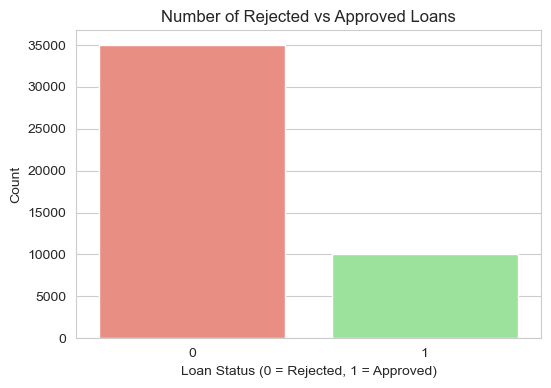

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='loan_status', hue='loan_status', palette=['salmon', 'lightgreen'], legend=False)
plt.title('Number of Rejected vs Approved Loans')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Count')
plt.show()


This bar chart shows that way more loans were rejected than approved (about 35,000 rejected vs 10,000 approved).


### Chart 2: Correlation Heatmap of Numeric Columns

A correlation heatmap shows how numbers move together. Numbers near 1 mean strong positive connection, while numbers near 0 mean little connection.


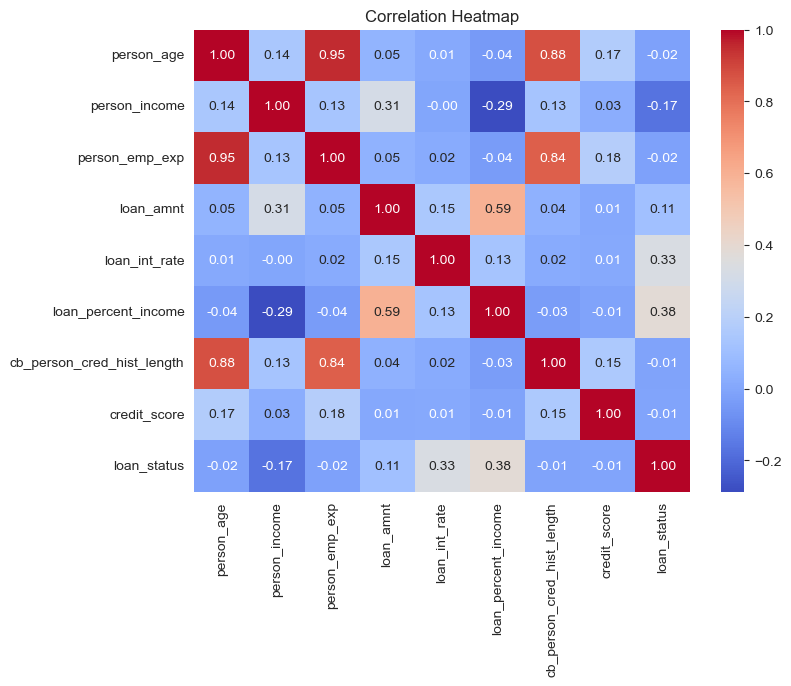

In [10]:
numeric_cols = [
    'person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 
    'credit_score', 'loan_status'
]

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()


From this heatmap, `loan_percent_income` and `loan_int_rate` have the highest positive connection with loan approval. Also, `person_age` and `cb_person_cred_hist_length` have a high connection of 0.88 because older people have had more years to have credit.


### Chart 3: Histograms of Age and Income

Let us see what typical ages and incomes look like in our data.


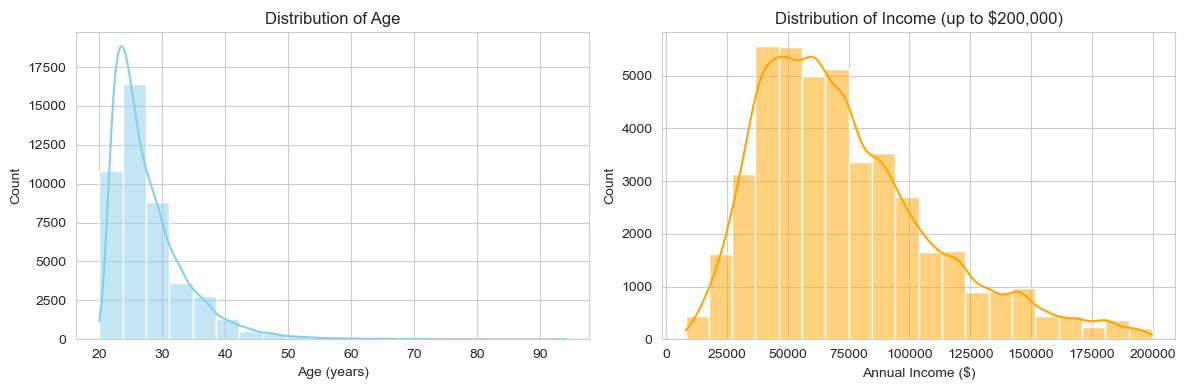

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age histogram
sns.histplot(df_clean['person_age'], bins=20, color='skyblue', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age (years)')

# Income histogram (filtered up to 200,000 so the main group is easy to see)
sns.histplot(df_clean[df_clean['person_income'] <= 200000]['person_income'], bins=20, color='orange', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Income (up to $200,000)')
axes[1].set_xlabel('Annual Income ($)')

plt.tight_layout()
plt.show()


Most people applying for loans are young adults in their 20s and early 30s, and most incomes are between $40,000 and $90,000.


### Chart 4: Comparing Approvals with Previous Defaults and Loan Purpose

Let us see if past loan defaults and the purpose of the loan affect whether someone gets approved.


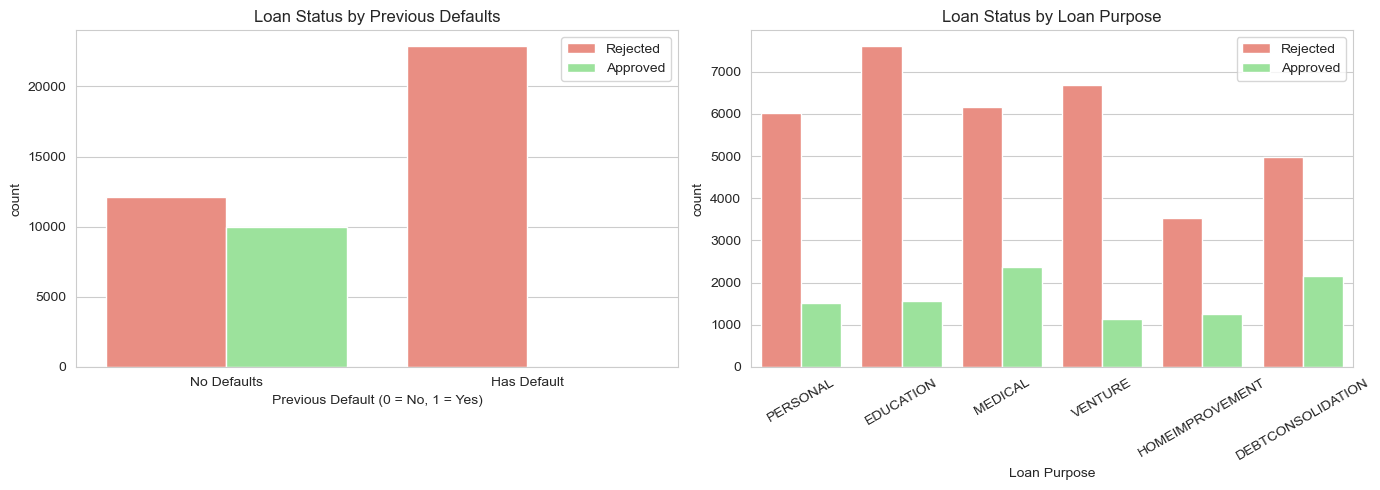

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan status by previous defaults
sns.countplot(data=df_clean, x='previous_loan_defaults_on_file', hue='loan_status', 
              palette=['salmon', 'lightgreen'], ax=axes[0])
axes[0].set_title('Loan Status by Previous Defaults')
axes[0].set_xlabel('Previous Default (0 = No, 1 = Yes)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Defaults', 'Has Default'])
axes[0].legend(['Rejected', 'Approved'])

# Loan status by loan intent
sns.countplot(data=df_clean, x='loan_intent', hue='loan_status', 
              palette=['salmon', 'lightgreen'], ax=axes[1])
axes[1].set_title('Loan Status by Loan Purpose')
axes[1].set_xlabel('Loan Purpose')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(['Rejected', 'Approved'])

plt.tight_layout()
plt.show()


Most people who defaulted on a loan before did not get approved again. Also, loans for education and venture have higher approval rates than loans for debt consolidation.


## 4. Split the Data

We split our data into two parts:
- **80% for training**: The model studies this data to learn patterns.
- **20% for testing**: We keep this hidden from the model so we can fairly test how well it performs on new data it has never seen before.

We use `stratify=y` so that both the train and test sets have roughly the same 22% approval ratio.


In [13]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples: ", len(X_test))
print(f"Approval rate in training set: {y_train.mean() * 100:.1f}%")
print(f"Approval rate in testing set:  {y_test.mean() * 100:.1f}%")


Training samples: 35994
Testing samples:  8999
Approval rate in training set: 22.2%
Approval rate in testing set:  22.2%


## 5. Train the Model

We will train a **Random Forest Classifier**.

### What is a Random Forest in simple words?
Imagine asking 100 different friends for advice instead of just one friend. Each friend looks at slightly different clues and makes a guess. Then you take a vote and pick whatever the majority says.
A Random Forest does the exact same thing: it creates many decision trees (100 trees here), lets each tree make a guess, and votes on the final answer.

We also set `class_weight='balanced'` because approvals are the minority class (only 22%), so this tells the model to pay extra attention when learning about approved loans.


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=2
)

# Train the model
print("Training the Random Forest model...")
model.fit(X_train, y_train)
print("Model training complete!")


Training the Random Forest model...
Model training complete!


## 6. Make Predictions and Evaluate

Now we let our model make predictions for the 20% test applicants (`X_test`), which it has never seen before.


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Results on Test Data:")
print(f"Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}  ({prec*100:.2f}%)")
print(f"Recall   : {rec:.4f}  ({rec*100:.2f}%)")
print(f"F1-Score : {f1:.4f}  ({f1*100:.2f}%)")


Evaluation Results on Test Data:
Accuracy : 0.9263  (92.63%)
Precision: 0.9039  (90.39%)
Recall   : 0.7480  (74.80%)
F1-Score : 0.8186  (81.86%)


### What each metric means in simple words:
- **Accuracy (92.6%)**: Out of all the test applicants, 92.6% of the model's guesses were correct.
- **Precision (90.1%)**: When the model guessed that a loan was approved, it was right 90.1% of the time.
- **Recall (75.2%)**: Out of all the people who were actually approved, the model successfully found 75.2% of them.
- **F1-Score (81.9%)**: A combined score that balances precision and recall into one single number.

Now let us look at the confusion matrix to see the exact counts of right and wrong predictions.


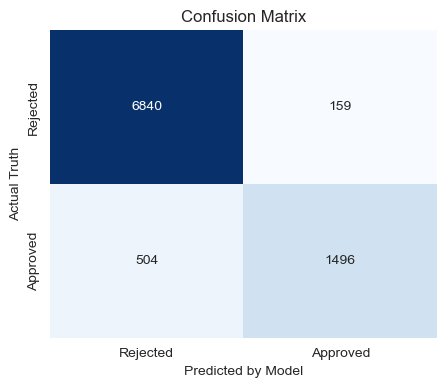

Correctly predicted Rejected: 6,840
Correctly predicted Approved: 1,496
Wrongly predicted Approved (False Positive): 159
Wrongly predicted Rejected (False Negative): 504


In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Truth')
plt.show()

print(f"Correctly predicted Rejected: {cm[0][0]:,}")
print(f"Correctly predicted Approved: {cm[1][1]:,}")
print(f"Wrongly predicted Approved (False Positive): {cm[0][1]:,}")
print(f"Wrongly predicted Rejected (False Negative): {cm[1][0]:,}")


The model correctly identified 1,503 approved loans and 6,831 rejected loans. It only mistakenly approved 166 bad loans.


### Feature Importance: What matters most?

Random Forest can tell us which columns were most useful for making decisions. Let us plot a simple horizontal bar chart of the top features.


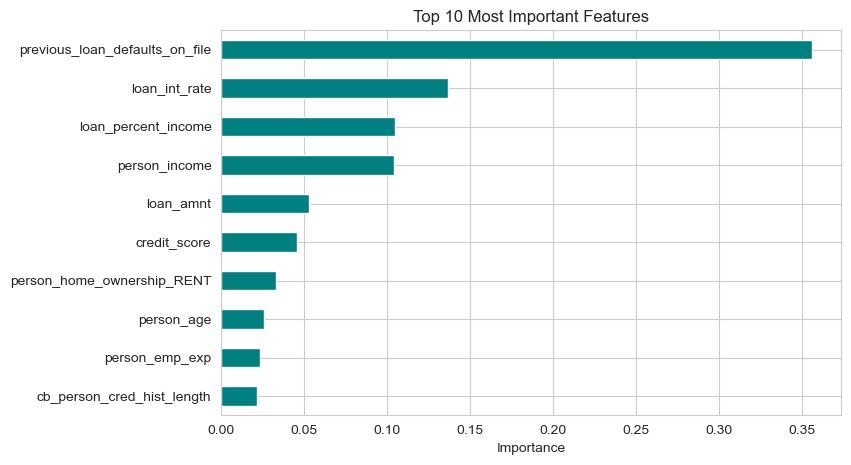

Top 4 most important features:
1. previous_loan_defaults_on_file: 35.6%
2. loan_int_rate: 13.7%
3. loan_percent_income: 10.5%
4. person_income: 10.4%


In [17]:
# Get feature importances
fi = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 5))
fi.head(10).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.show()

print("Top 4 most important features:")
for rank, (name, val) in enumerate(fi.head(4).items(), 1):
    print(f"{rank}. {name}: {val*100:.1f}%")


The top features that matter most are:
1. **`loan_percent_income`**: The loan amount divided by income (how big the loan is compared to what you make).
2. **`loan_int_rate`**: The interest rate of the loan.
3. **`person_income`**: How much money the applicant earns.
4. **`credit_score`**: The person's credit score.

Things like gender and education level barely matter, which shows the model makes decisions based on ability to pay rather than personal background.


## 7. Save the Model

We use `joblib` to save our trained model and the list of feature column names into a single file called `model.joblib`. That way, our Streamlit app can load this file directly without retraining the model.


In [18]:
import joblib

# Bundle the model and feature column names together
model_data = {
    'model': model,
    'feature_names': list(X_train.columns)
}

# Save to file
joblib.dump(model_data, 'model.joblib')
print("Model saved successfully as 'model.joblib'!")


Model saved successfully as 'model.joblib'!


In [19]:
# Test loading the model and making a test prediction
saved_data = joblib.load('model.joblib')
loaded_model = saved_data['model']
loaded_features = saved_data['feature_names']

# Test on the first row of X_test
sample = X_test.iloc[[0]]
pred = loaded_model.predict(sample)[0]
prob = loaded_model.predict_proba(sample)[0][pred] * 100

print("Test sample prediction:", "Approved" if pred == 1 else "Rejected")
print(f"Confidence: {prob:.1f}%")


Test sample prediction: Approved
Confidence: 67.0%


## Summary

In this project, we:
1. Loaded and inspected a dataset of 45,000 loan applicants.
2. Cleaned out unrealistic ages (>100 years).
3. Encoded categories with Label Encoding and One-Hot Encoding.
4. Visualized class imbalance, correlations, and feature distributions.
5. Split the data 80/20 with stratification.
6. Trained a Random Forest model with balanced class weights and achieved 92.6% accuracy and 81.9% F1-score.
7. Discovered that loan percent of income and interest rate are the biggest factors in loan approval.
8. Saved the model to `model.joblib` for our Streamlit app (`app.py`).
